# The MNIST database

## 1.The dataset
### 1.1. Import all needed modules and define constants

In [2]:
import numpy as np
from tensorflow.keras.datasets import mnist
import keras
import sys
import matplotlib.pyplot as plt

NB_CLASSES = 10
NB_INPUTS = 784 # 28x28

### 1.2 Import the data

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step


In [4]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


### 1.3. Images display

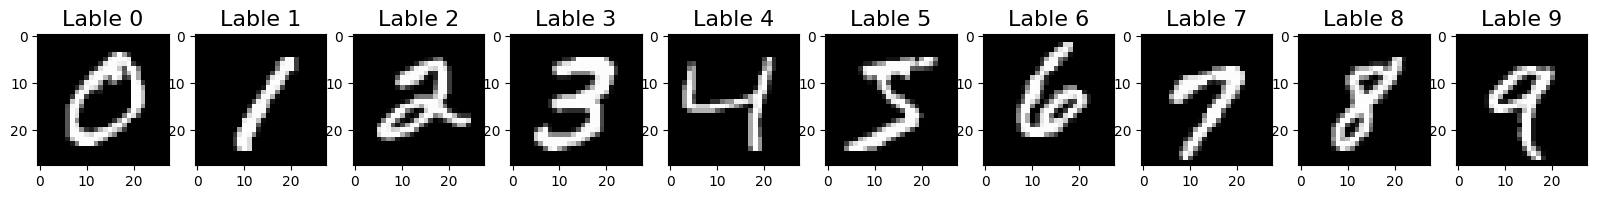

In [5]:
f, ax = plt.subplots(1, NB_CLASSES, figsize=(20,20))

for i in range(0, NB_CLASSES):
    sample = x_train[y_train == i][0]
    ax[i].imshow(sample, cmap='gray')
    ax[i].set_title(f'Lable {i}', fontsize=16)

In [6]:
image_index = 300
for row in x_train[image_index]:
    for pixel in row:
        sys.stdout.write(f'{pixel:3d} ')
    sys.stdout.write('\n')

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 138 238 217  68   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 150 254 254 254 232   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0  63 224 254 145 254 240  22   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0  15 160 253 254 254 187 254 180   0   0   0   0 

### 1.4 One hot encoding the y data

In [7]:
print(y_train[0])

5


In [8]:
y_test_initial = y_test.copy()
y_train = keras.utils.to_categorical(y_train, NB_CLASSES)
y_test = keras.utils.to_categorical(y_test, NB_CLASSES)

In [9]:
print(y_train[0])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


### 1.5 Prepare x data

#### 1.5.1. Flatten the images _(28x28 vector -> 784x1)_

In [10]:
x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)
print(x_train.shape, y_train.shape)


(60000, 784) (60000, 10)


#### 1.5.2 Normalize the values _([0, 255] -> [0, 1])_

In [11]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [12]:
print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (60000, 784)
Test shape: (10000, 784)


---

### 1.6. Functions definition

In [13]:
# Softmax
def softmax(x):
    x = x - np.max(x,axis=1,keepdims=True)
    expx = np.exp(x)
    return expx/np.sum(expx,axis=1,keepdims=True)

# Log loss function
# We add an epsilon just to avoid an error in the case where we get: np.log(0) -> -inf
def loss(Y,P):
    eps=1e-12
    return -np.mean(np.sum(Y*np.log(P+eps),axis=1))

def accuracy(Y, P):
    return np.mean(np.argmax(P, axis=1) == np.argmax(Y, axis=1))

def error_rate(Y, P):
    return 1.0 - accuracy(Y, P)

## 2. Classification model
### 2.1 Linear model

In [14]:
# Initialize weights and biases
np.random.seed(42)
A = np.random.randn(NB_CLASSES, NB_INPUTS)*0.01 # random small weights
b = np.zeros((1, NB_CLASSES)) # random biases

In [15]:
def gradient_descent(X,Y, P,n):
    dA =  (P - Y).T @ X / n
    db = sum((P - Y)) /n
    return dA, db

In [16]:
LEARNING_RATE = 0.2
loss_history_linear = []
accuracy_history_linear = []
for i in range(500):
    O = x_train @ A.T + b
    P = softmax(O)  # predicted probabilities

    # Loss
    L = loss(y_train, P)
    loss_history_linear.append(L)
    accuracy_history_linear.append(accuracy(y_train, P))

    dA, db = gradient_descent(x_train, y_train, P, x_train.shape[0])
    # update parameters
    A -= LEARNING_RATE * dA
    b -= LEARNING_RATE * db

    # print results
    print(f'Loss at iteration {i}: {L:.4f}')

Loss at iteration 0: 2.3399
Loss at iteration 1: 2.1231
Loss at iteration 2: 1.9458
Loss at iteration 3: 1.7936
Loss at iteration 4: 1.6632
Loss at iteration 5: 1.5516
Loss at iteration 6: 1.4559
Loss at iteration 7: 1.3735
Loss at iteration 8: 1.3021
Loss at iteration 9: 1.2400
Loss at iteration 10: 1.1856
Loss at iteration 11: 1.1376
Loss at iteration 12: 1.0950
Loss at iteration 13: 1.0569
Loss at iteration 14: 1.0228
Loss at iteration 15: 0.9920
Loss at iteration 16: 0.9641
Loss at iteration 17: 0.9386
Loss at iteration 18: 0.9154
Loss at iteration 19: 0.8940
Loss at iteration 20: 0.8743
Loss at iteration 21: 0.8561
Loss at iteration 22: 0.8392
Loss at iteration 23: 0.8235
Loss at iteration 24: 0.8088
Loss at iteration 25: 0.7951
Loss at iteration 26: 0.7822
Loss at iteration 27: 0.7701
Loss at iteration 28: 0.7587
Loss at iteration 29: 0.7479
Loss at iteration 30: 0.7378
Loss at iteration 31: 0.7281
Loss at iteration 32: 0.7190
Loss at iteration 33: 0.7103
Loss at iteration 34: 0.

### 2. Model with 1 hidden layer

In [17]:
def relu(x):
    return np.maximum(0.0, x)

def relu_derivative(x):
    # 1 if x > 0 else 0
    return (x > 0).astype(float)

In [18]:
p1 = 256 # number of neurons in the hidden layer
np.random.seed(42)

# initialize weights and biases for the hidden layer
# He initialization to avoid vanishing/exploding gradients
a1_h1 = np.random.randn(p1, NB_INPUTS) * np.sqrt(2. / p1) 
b1_h1 = np.zeros((1, p1))
a2_h1 = np.random.randn(NB_CLASSES, p1) * np.sqrt(2. / p1)
b2_h1 = np.zeros((1, NB_CLASSES))

print(f'a1_h1.shape: {a1_h1.shape} | b1_h1.shape: {b1_h1.shape}')
print(f'a2_h1.shape: {a2_h1.shape} | b2_h1.shape: {b2_h1.shape}')

a1_h1.shape: (256, 784) | b1_h1.shape: (1, 256)
a2_h1.shape: (10, 256) | b2_h1.shape: (1, 10)


In [19]:
loss_h1_history = []
accuracy_h1_history = []

for i in range(500):
    O1 = x_train @ a1_h1.T + b1_h1
    Z1 = relu(O1)
    O2 = Z1 @ a2_h1.T + b2_h1
    P = softmax(O2)

    L = loss(y_train, P)
    loss_h1_history.append(L)
    accuracy_h1_history.append(accuracy(y_train, P))

    # Backpropagation
    dO2 = (P - y_train)/x_train.shape[0]
    da2_h1 = dO2.T @ Z1
    db2_h1 = np.sum(dO2, axis=0, keepdims=True)

    dZ1 = dO2 @ a2_h1* relu_derivative(O1)
    da1_h1 = dZ1.T @ x_train
    db1_h1 = np.sum(dZ1, axis=0, keepdims=True)

    # Update parameters
    a2_h1 -= LEARNING_RATE * da2_h1
    b2_h1 -= LEARNING_RATE * db2_h1
    a1_h1 -= LEARNING_RATE * da1_h1
    b1_h1 -= LEARNING_RATE * db1_h1

    # print results
    print(f'Loss at iteration {i}: {L:.4f}, Accuracy: {accuracy_h1_history[-1]*100:.2f}%') 

Loss at iteration 0: 2.8701, Accuracy: 7.94%
Loss at iteration 1: 2.2903, Accuracy: 22.23%
Loss at iteration 2: 1.9418, Accuracy: 36.56%
Loss at iteration 3: 1.7181, Accuracy: 51.55%
Loss at iteration 4: 1.5462, Accuracy: 59.01%
Loss at iteration 5: 1.4045, Accuracy: 64.40%
Loss at iteration 6: 1.2867, Accuracy: 68.14%
Loss at iteration 7: 1.1883, Accuracy: 71.07%
Loss at iteration 8: 1.1054, Accuracy: 73.50%
Loss at iteration 9: 1.0352, Accuracy: 75.39%
Loss at iteration 10: 0.9752, Accuracy: 76.99%
Loss at iteration 11: 0.9235, Accuracy: 78.20%
Loss at iteration 12: 0.8787, Accuracy: 79.25%
Loss at iteration 13: 0.8396, Accuracy: 80.17%
Loss at iteration 14: 0.8052, Accuracy: 80.93%
Loss at iteration 15: 0.7747, Accuracy: 81.53%
Loss at iteration 16: 0.7475, Accuracy: 82.07%
Loss at iteration 17: 0.7232, Accuracy: 82.57%
Loss at iteration 18: 0.7013, Accuracy: 83.03%
Loss at iteration 19: 0.6815, Accuracy: 83.44%
Loss at iteration 20: 0.6634, Accuracy: 83.78%
Loss at iteration 21: 0.

### 2. Model with 2 hidden layers

In [20]:
p1 = 256 # number of neurons in the hidden layer
p2 = 128 # number of neurons in the second hidden layer
np.random.seed(42)

# initialize weights and biases for the hidden layer
# He initialization to avoid vanishing/exploding gradients
a1_h2 = np.random.randn(p1, NB_INPUTS) * np.sqrt(2. / p1) 
b1_h2 = np.zeros((1, p1))
a2_h2 = np.random.randn(p2, p1) * np.sqrt(2. / p1)
b2_h2 = np.zeros((1, p2))
a3_h2 = np.random.randn(NB_CLASSES, p2) * np.sqrt(2. / p2)
b3_h2 = np.zeros((1, NB_CLASSES))

print(f'a1_h2.shape: {a1_h2.shape} | b1_h2.shape: {b1_h2.shape}')
print(f'a2_h2.shape: {a2_h2.shape} | b2_h2.shape: {b2_h2.shape}')
print(f'a3_h2.shape: {a3_h2.shape} | b3_h2.shape: {b3_h2.shape}')

a1_h2.shape: (256, 784) | b1_h2.shape: (1, 256)
a2_h2.shape: (128, 256) | b2_h2.shape: (1, 128)
a3_h2.shape: (10, 128) | b3_h2.shape: (1, 10)


In [21]:
loss_h2_history = []
accuracy_h2_history = []
ITER = 500

for i in range(ITER):
    O1 = x_train @ a1_h2.T + b1_h2
    Z1 = relu(O1)

    O2 = Z1 @ a2_h2.T + b2_h2
    Z2 = relu(O2)

    O3 = Z2 @ a3_h2.T + b3_h2
    P = softmax(O3)

    L = loss(y_train, P)
    loss_h2_history.append(L)
    accuracy_h2_history.append(accuracy(y_train, P))

    # Backpropagation

    # Layer 3
    dO3 = (P - y_train)/x_train.shape[0]
    da3_h2 = dO3.T @ Z2
    db3_h2 = np.sum(dO3, axis=0, keepdims=True)

    # Layer 2
    dZ2 = dO3 @ a3_h2 * relu_derivative(O2)
    da2_h2 = dZ2.T @ Z1
    db2_h2 = np.sum(dZ2, axis=0, keepdims=True)

    # Layer 1
    dZ1 = dZ2 @ a2_h2 * relu_derivative(O1)
    da1_h2 = dZ1.T @ x_train
    db1_h2 = np.sum(dZ1, axis=0, keepdims=True)

    # Update parameters
    a2_h2 -= LEARNING_RATE * da2_h2
    b2_h2 -= LEARNING_RATE * db2_h2
    a3_h2 -= LEARNING_RATE * da3_h2
    b3_h2 -= LEARNING_RATE * db3_h2
    a1_h2 -= LEARNING_RATE * da1_h2
    b1_h2 -= LEARNING_RATE * db1_h2

    # print results
    print(f'Loss at iteration {i}: {L:.4f}, Accuracy: {accuracy_h2_history[-1]*100:.2f}%')

Loss at iteration 0: 2.6576, Accuracy: 8.03%
Loss at iteration 1: 2.2133, Accuracy: 24.75%
Loss at iteration 2: 1.9535, Accuracy: 39.14%
Loss at iteration 3: 1.7596, Accuracy: 50.23%
Loss at iteration 4: 1.5895, Accuracy: 58.11%
Loss at iteration 5: 1.4358, Accuracy: 63.67%
Loss at iteration 6: 1.2999, Accuracy: 67.87%
Loss at iteration 7: 1.1831, Accuracy: 70.90%
Loss at iteration 8: 1.0850, Accuracy: 73.21%
Loss at iteration 9: 1.0065, Accuracy: 74.49%
Loss at iteration 10: 0.9527, Accuracy: 75.00%
Loss at iteration 11: 0.9643, Accuracy: 70.56%
Loss at iteration 12: 1.1004, Accuracy: 61.86%
Loss at iteration 13: 1.3796, Accuracy: 61.02%
Loss at iteration 14: 1.1334, Accuracy: 62.63%
Loss at iteration 15: 0.9007, Accuracy: 71.37%
Loss at iteration 16: 0.8170, Accuracy: 75.19%
Loss at iteration 17: 0.7272, Accuracy: 80.14%
Loss at iteration 18: 0.6938, Accuracy: 80.17%
Loss at iteration 19: 0.6658, Accuracy: 81.86%
Loss at iteration 20: 0.6496, Accuracy: 81.04%
Loss at iteration 21: 0.

## 3. Model comparison : evaluation, error analysis and discussion

### 3.1 Error rate 
#### 3.1.1 Error rate on training set

In [22]:
# Functions to compute the activations of the hidden layers
def activation_hidden_layer_h1(X):
    Z1 = relu(X @ a1_h1.T + b1_h1) # hidden layer activation
    return softmax(Z1 @ a2_h1.T + b2_h1)

def activation_hidden_layer_h2(X):
    Z1 = relu(X @ a1_h2.T + b1_h2) # first hidden layer activation
    Z2 = relu(Z1 @ a2_h2.T + b2_h2) # second hidden layer activation
    return softmax(Z2 @ a3_h2.T + b3_h2)

In [23]:
error_train = {}

# Prediction on the training set
pred_train_lin  = softmax(x_train @ A.T + b) # predicted class by the linear model
pred_train_h1   = activation_hidden_layer_h1(x_train) # predicted class by the 1 hidden layer model

# Linear model
error_train['Linear'] = error_rate(y_train, pred_train_lin)

# 1 hidden layer
error_train['1HL'] = error_rate(y_train, pred_train_h1)

# 2 hidden layers
error_train['2HL'] = error_rate(y_train, activation_hidden_layer_h2(x_train))

print(f"Linear model error - Train error: {error_train['Linear']*100:.2f}% ")
print(f"1 hidden layer error - Train error: {error_train['1HL']*100:.2f}%")
print(f"2 hidden layers error - Train error: {error_train['2HL']*100:.2f}%")

Linear model error - Train error: 9.58% 
1 hidden layer error - Train error: 5.64%
2 hidden layers error - Train error: 3.86%


#### 3.1.2 Error rate on test set 

In [24]:
error_test = {}
# Prediction on the test set
pred_test_lin  = softmax(x_test @ A.T + b) # predicted class by the linear model
pred_test_h1   = activation_hidden_layer_h1(x_test) # predicted class by the 1 hidden layer model

# Linear model
error_test['Linear'] = error_rate(y_test, pred_test_lin)

# 1 hidden layer
error_test['1HL'] = error_rate(y_test, pred_test_h1)

# 2 hidden layers
error_test['2HL'] = error_rate(y_test, activation_hidden_layer_h2(x_test))

print(f"Linear model error - Test error: {error_test['Linear']*100:.2f}% ")
print(f"1 hidden layer error - Test error: {error_test['1HL']*100:.2f}%")
print(f"2 hidden layers error - Test error: {error_test['2HL']*100:.2f}%")

Linear model error - Test error: 9.01% 
1 hidden layer error - Test error: 5.82%
2 hidden layers error - Test error: 4.34%


#### 3.1.3 Error rate comparison

In [25]:
models = ['Linear', '1HL', '2HL']
    
# print result under table format
print(f"{'Model':<20} {'Train error':>22} {'Test error':>22}")
print("-" * 75)

# print results
for i in range(len(models)):
    print(f"{models[i]:<20} {error_train[models[i]]*100:>20.2f}% {error_test[models[i]]*100:>20.2f}%")


Model                           Train error             Test error
---------------------------------------------------------------------------
Linear                               9.58%                 9.01%
1HL                                  5.64%                 5.82%
2HL                                  3.86%                 4.34%


### 3.2 Miss classified digits & explanation of the error
#### 3.2.1 Ambigous digit

In [26]:
true_labels = y_test_initial

# Classe de prédiction 
pred_lin = np.argmax(pred_test_lin, axis=1) # (10000,) int between 0-9
pred_h1  = np.argmax(pred_test_h1,  axis=1) # (10000,) int between 0-9

# Indices of missclassified images
erreurs_lin = np.where(pred_lin != true_labels)[0]
erreurs_h1  = np.where(pred_h1  != true_labels)[0]

print(f"Linear model : {len(erreurs_lin)} errors out of {len(true_labels)}")
print(f"MLP 1 hidden layer : {len(erreurs_h1)} errors out of {len(true_labels)}")

# Count errors per class
error_count_lin = np.zeros(NB_CLASSES, dtype=int)
error_count_h1  = np.zeros(NB_CLASSES, dtype=int)

for i in erreurs_lin:
    error_count_lin[true_labels[i]] += 1 

for i in erreurs_h1:
    error_count_h1[true_labels[i]] += 1

# Print errors per class
for i in range(NB_CLASSES):
    print(f"Class {i}:     Linear model: {error_count_lin[i]} errors,    1 hidden layer: {error_count_h1[i]} errors")

Linear model : 901 errors out of 10000
MLP 1 hidden layer : 582 errors out of 10000
Class 0:     Linear model: 23 errors,    1 hidden layer: 19 errors
Class 1:     Linear model: 34 errors,    1 hidden layer: 20 errors
Class 2:     Linear model: 134 errors,    1 hidden layer: 74 errors
Class 3:     Linear model: 106 errors,    1 hidden layer: 64 errors
Class 4:     Linear model: 72 errors,    1 hidden layer: 55 errors
Class 5:     Linear model: 139 errors,    1 hidden layer: 78 errors
Class 6:     Linear model: 55 errors,    1 hidden layer: 39 errors
Class 7:     Linear model: 98 errors,    1 hidden layer: 71 errors
Class 8:     Linear model: 124 errors,    1 hidden layer: 78 errors
Class 9:     Linear model: 116 errors,    1 hidden layer: 84 errors


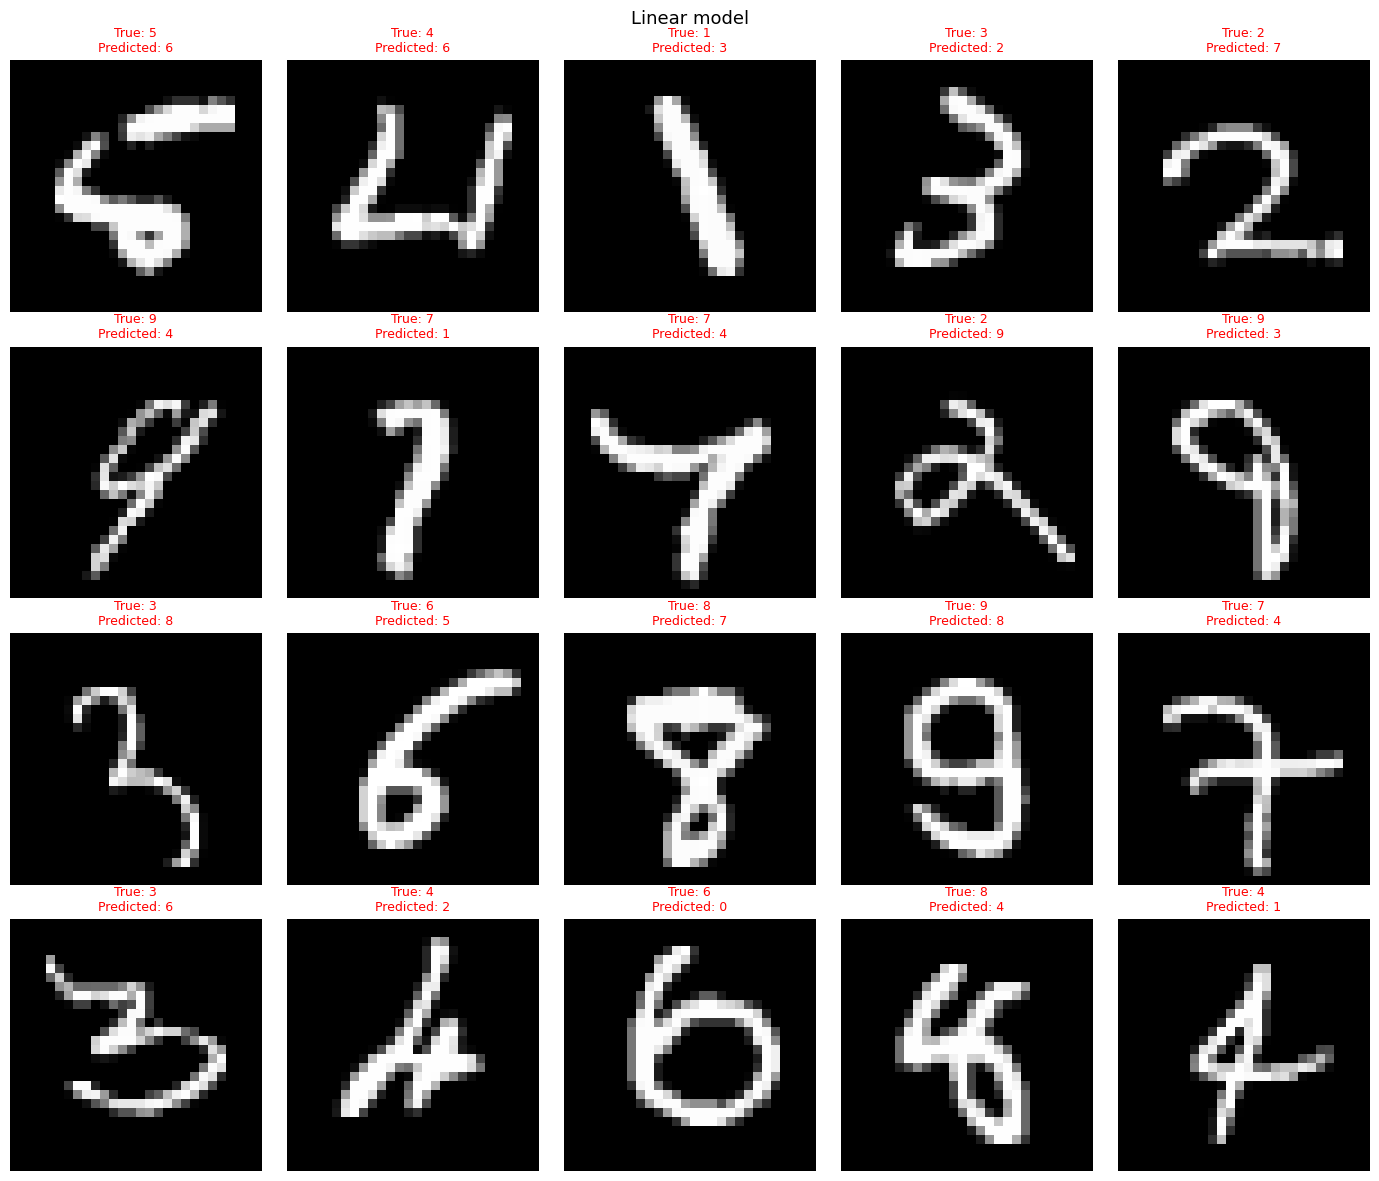

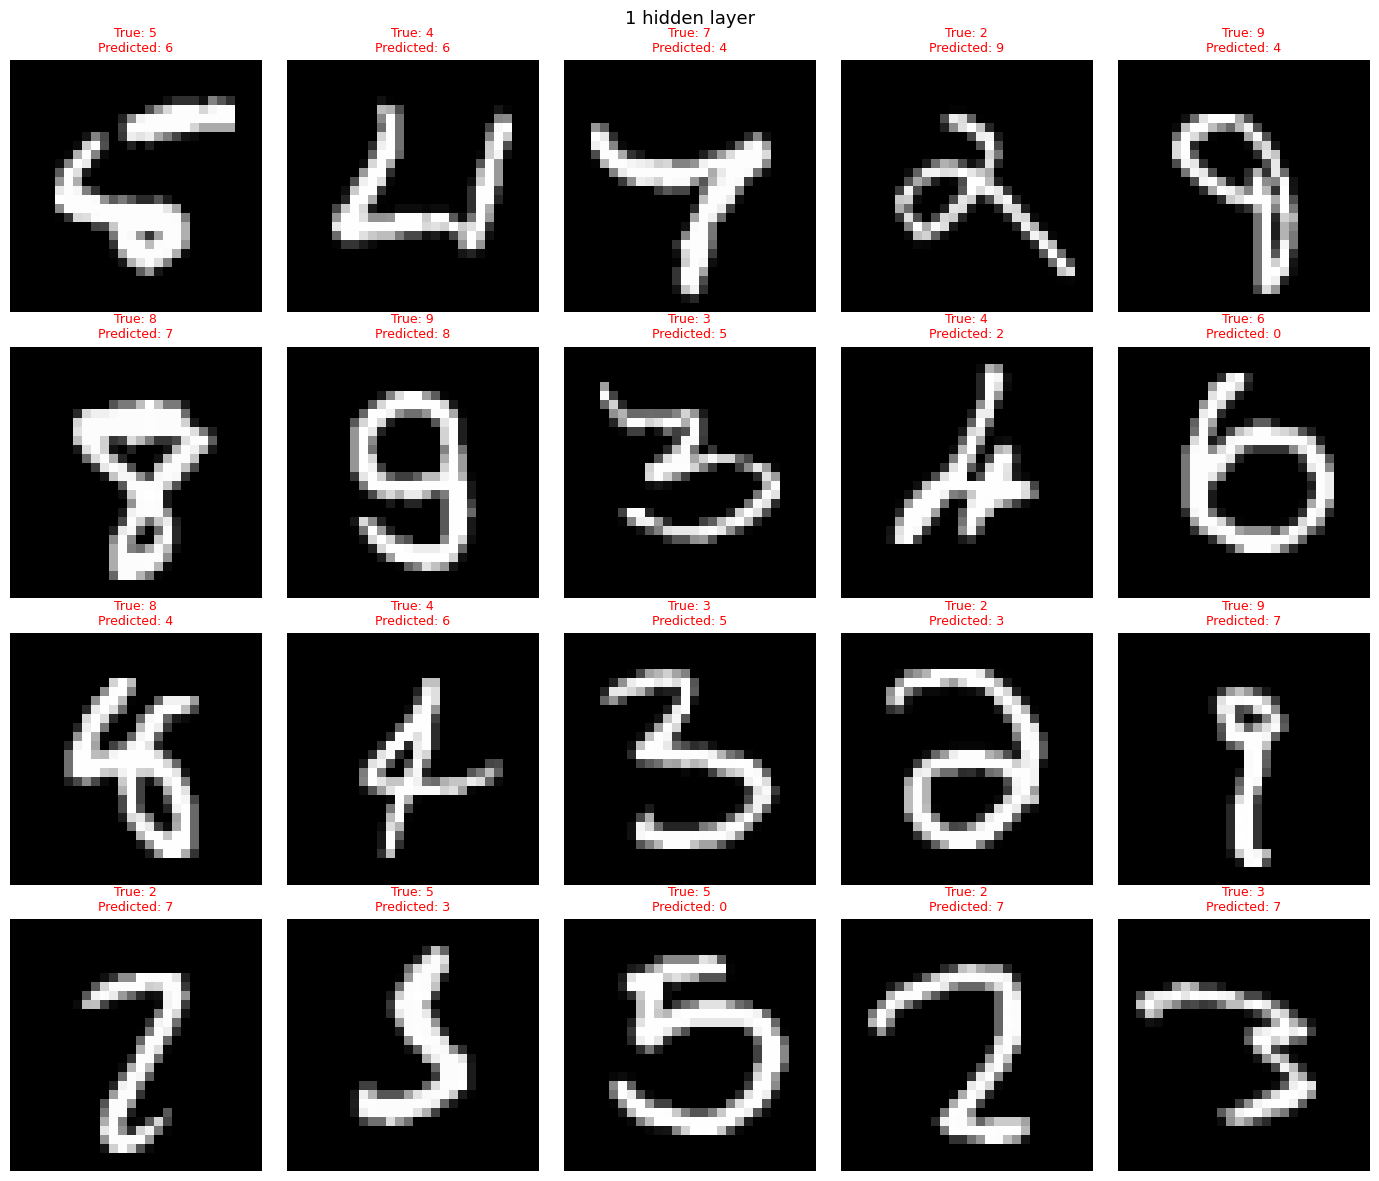

In [27]:
# sample of 20 misclassified images for each model
def display_errors(erreurs_idx, x_test, true_labels, pred, titre, n_show=20):

    fig, axes = plt.subplots(4, 5, figsize=(14, 12))
    axes = axes.ravel()
    for j, i in enumerate(erreurs_idx[:n_show]):
        i = int(i)                          
        img = x_test[i].reshape(28, 28)
        axes[j].imshow(img, cmap='gray')
        axes[j].set_title(
            f'True: {true_labels[i]}\nPredicted: {pred[i]}',fontsize=9, color='red')
        axes[j].axis('off')
    plt.suptitle(titre, fontsize=13)
    plt.tight_layout()
    plt.show()

display_errors(erreurs_lin, x_test, true_labels, pred_lin, "Linear model")
display_errors(erreurs_h1,  x_test, true_labels, pred_h1,  "1 hidden layer")

### Atypical Handwriting

In [30]:
from sklearn.decomposition import PCA

# Reduce dimension from 784 -> 2
pca_reduced =  PCA(n_components = 2)
X_pca = pca_reduced.fit_transform(x_test)

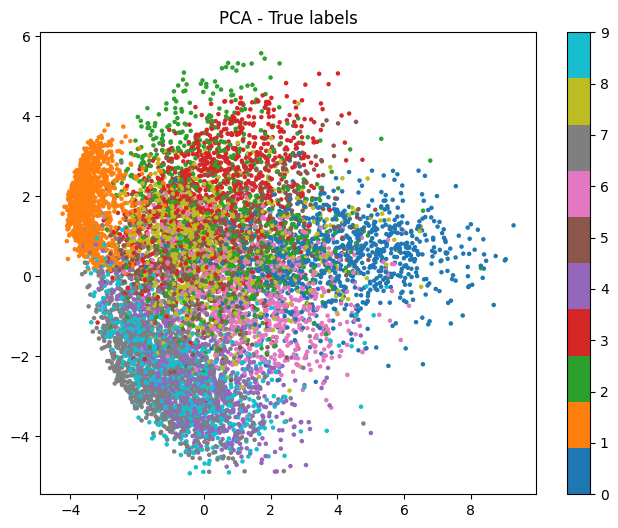

In [31]:
# each color = 1 digit, clusters overlapping each other => ambiguous digit
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=true_labels, cmap='tab10', s=5)
plt.colorbar()
plt.title("PCA - True labels")
plt.show()

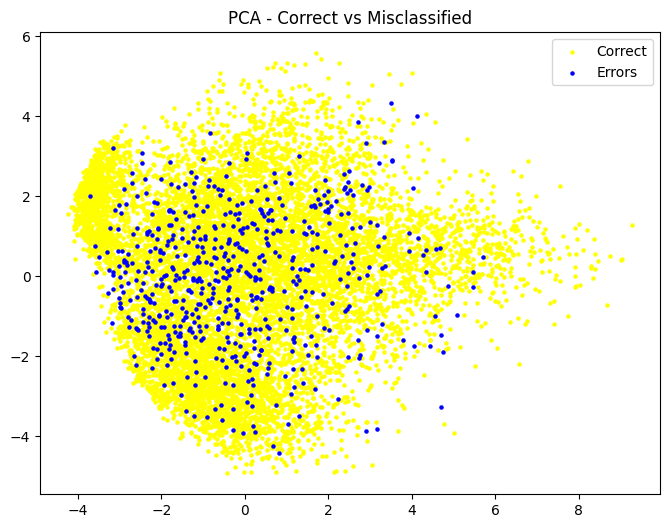

In [36]:
# the errors that are overlapping centrally are susceptible to be the ambiguous digits and the one isolated corresponds to the atypical handwriting
correct = (pred_h1 == true_labels)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[correct,0], X_pca[correct,1], c='yellow', s=5, label='Correct')
plt.scatter(X_pca[~correct,0], X_pca[~correct,1], c='blue', s=5, label='Misclassified')

plt.legend()
plt.title("PCA - Correct vs Misclassified digits")
plt.show()

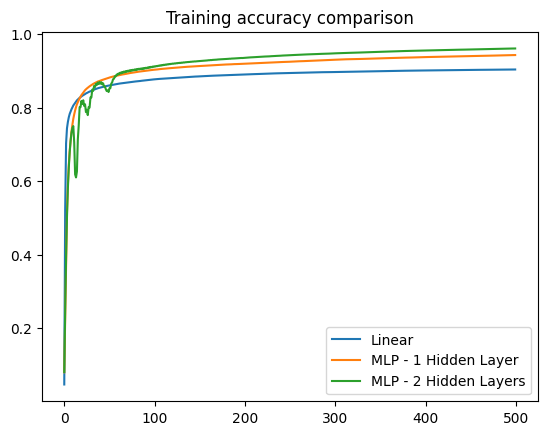

In [39]:
plt.plot(accuracy_history_linear, label="Linear")
plt.plot(accuracy_h1_history, label="MLP - 1 Hidden Layer")
plt.plot(accuracy_h2_history, label="MLP - 2 Hidden Layers")
plt.legend()
plt.title("Training accuracy comparison")
plt.show()